In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]= '3'
import numpy as np
from scipy.io import loadmat, savemat
from copy import deepcopy
import matplotlib.pyplot as plt
import multielec_src.fitting as fitting
import multielec_src.multielec_utils as mutils
import statsmodels.api as sm
import torch
import gpytorch
from gpytorch.means import ConstantMean, LinearMean, ZeroMean
from gpytorch.kernels import RBFKernel
from gpytorch.likelihoods import GaussianLikelihood
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from copy import deepcopy

%matplotlib inline

In [2]:
def global_selectivity(probs_2d):
    target_probs = np.max(probs_2d, axis=0)
    target_inds = np.argmax(probs_2d, axis=0)
    selectivity = np.zeros_like(target_probs)

    for i, ind in enumerate(target_inds):
        other_inds = np.setdiff1d(np.arange(len(probs_2d)), ind)
        selectivity[i] = target_probs[i] * (1 - np.amax(probs_2d[other_inds, i]))
    
    return selectivity

In [3]:
dataset = '2020-09-29-2'
basename = f'/Volumes/Analysis/{dataset}/gsort'
ESTIM_ANALYSIS_BASE = '/Volumes/Lab/Users/praful/outputs/pp_out'
datarun = 'data008'
wnoise = 'kilosort_data006/data006'

# Load electrical data and g-sort data
outpath = os.path.join(basename, datarun, wnoise)
parameters = loadmat(os.path.join(outpath, 'parameters.mat'))

cells = parameters['cells'].flatten()
patterns = parameters['patterns'].flatten()
num_cells = len(cells)
num_patterns = max(patterns)
num_movies = parameters['movies'].flatten()[0]

all_trials = np.array(np.memmap(os.path.join(outpath, 'trial.dat'),mode='r',shape=(num_patterns, num_movies), dtype='int16'), dtype=int)
amps_gsort = mutils.get_stim_amps_newlv(os.path.join(ESTIM_ANALYSIS_BASE, dataset, datarun), 
                                        len(all_trials))

244 218


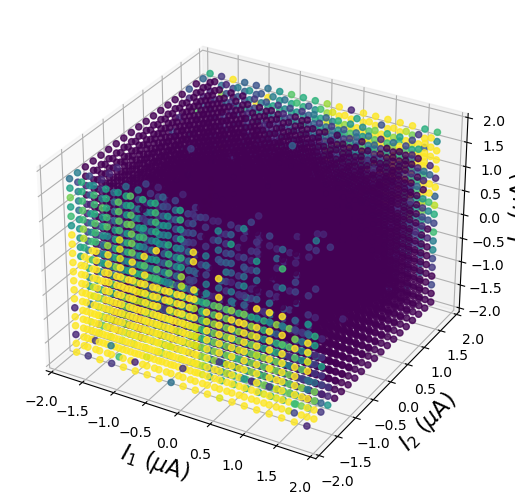

244 173


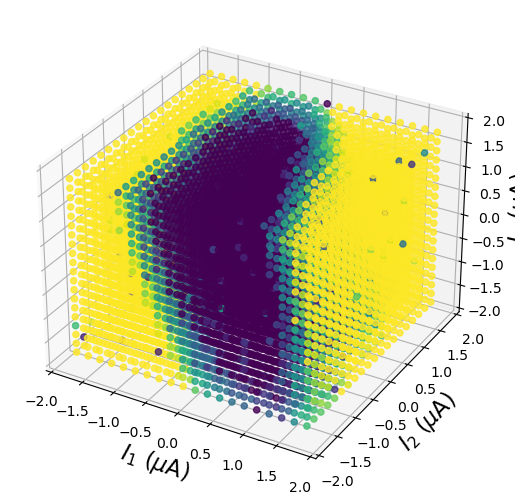

311 219


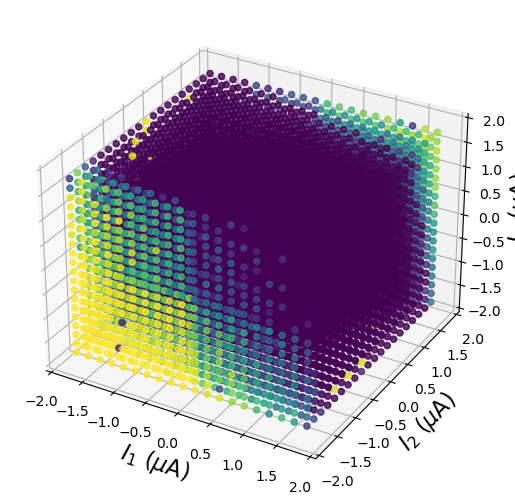

311 222


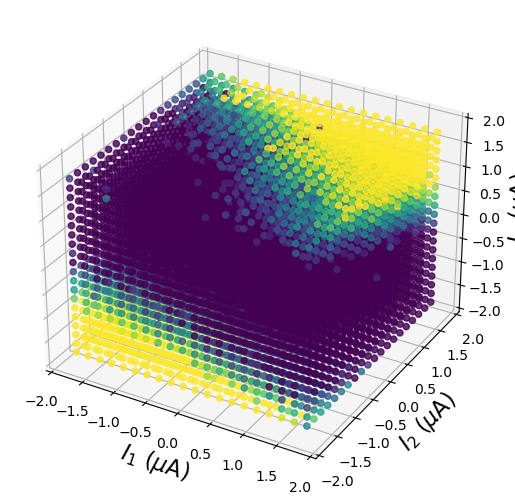

244 691


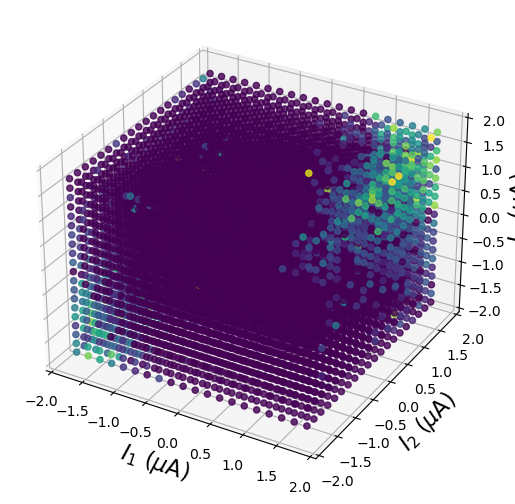

311 218


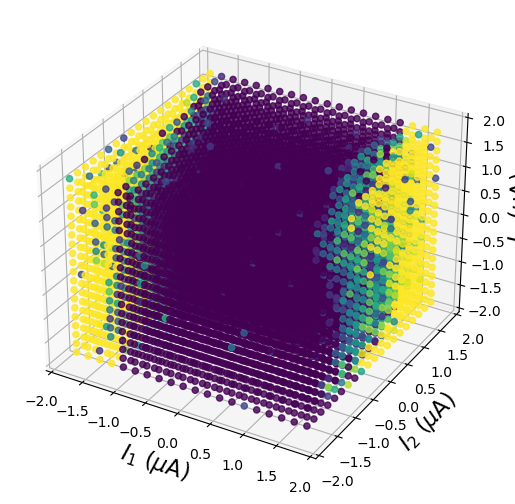

(3, 8000)
244 0.99


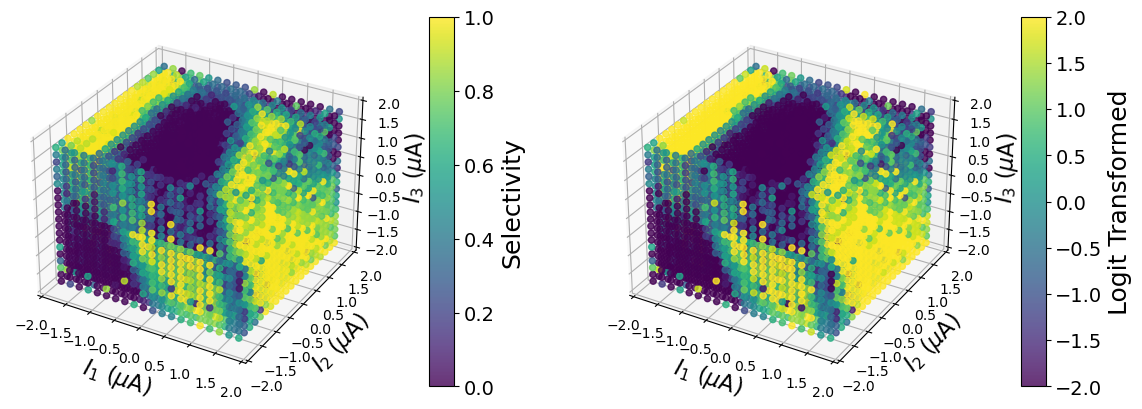

(3, 8000)
311 0.99


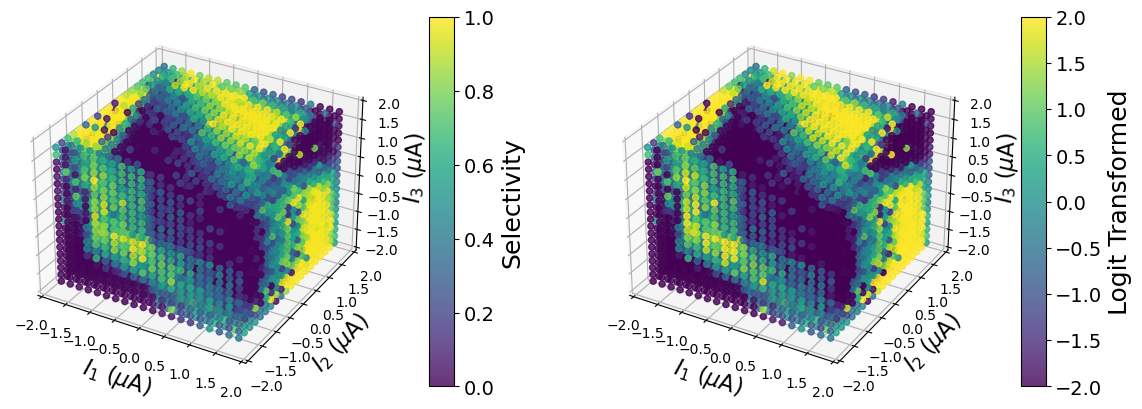

In [4]:
path = os.path.join(basename, datarun, wnoise)
file_list = os.listdir(path)

ms = [1, 2, 3, 4, 5]
zero_prob = 0.01
slope_bound = 100
R2_thresh = 0.025
reg_param = 0.5
method = 'L-BFGS-B'
reg_method = 'l2'

patterns = {}
for file in file_list:
    if file.endswith('.mat') and file.startswith('fit'):
        pattern_cell = file.split('.mat')[0].split('_')[-1]
        p, c = pattern_cell.replace('p', '').split('c')
        p = int(p)
        c = int(c)
        print(p, c)
        
        params = loadmat(os.path.join(path, file))['params_true']
        X = loadmat(os.path.join(path, file))['amps_fit']
        probs_fit = loadmat(os.path.join(path, file))['probs_fit'].flatten()
        
        # Find indices of rows in A corresponding to rows in B, preserving order
        indices = [np.where(np.all(amps_gsort == row, axis=1))[0][0] for row in X]
        remaining_inds = np.setdiff1d(np.arange(len(amps_gsort)), indices)
        amps_remaining = deepcopy(amps_gsort[remaining_inds])

        probs_flipped = np.zeros(len(amps_gsort))
        probs_flipped[indices] = probs_fit

        probs_remaining = fitting.sigmoidND_nonlinear(sm.add_constant(amps_remaining, has_constant='add'),
                                                    params)
        probs_flipped[remaining_inds] = np.where(probs_remaining > 0.5, 1, 0)
        T = np.ones_like(probs_flipped) * 20

        # At this point X has all the amps, and probs_fit has all the empirical probabilities

        fig = plt.figure(2)
        fig.clear()
        ax = Axes3D(fig, auto_add_to_figure=False)
        fig.add_axes(ax)
        plt.xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
        plt.ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
        plt.xlim(-2, 2)
        plt.ylim(-2, 2)
        ax.set_zlim(-2, 2)
        ax.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)

        scat = ax.scatter(amps_gsort[:, 0], 
                            amps_gsort[:, 1],
                            amps_gsort[:, 2], marker='o', 
                            c=probs_flipped, s=20, alpha=0.8, vmin=0, vmax=1)
        plt.show()

        if p not in patterns:
            patterns[p] = []
        patterns[p].append((c, probs_flipped))

selectivities = {}
for p in patterns:
    cells = [c for c, _ in patterns[p]]
    probs_all = np.vstack([probs for _, probs in patterns[p]])
    print(probs_all.shape)

    if len(cells) < 2:
        continue

    selectivity = global_selectivity(probs_all)
    selectivity = np.clip(selectivity, 1e-2, 1-1e-2)

    selectivity_logit = np.log(selectivity/(1-selectivity))
    selectivities[p] = (selectivity, selectivity_logit, probs_all)
    print(p, np.amax(selectivity))

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(121, projection='3d')
    scat1 = ax1.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2],
                        c=selectivity, marker='o', s=20, alpha=0.8, vmin=0, vmax=1)
    ax1.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax1.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax1.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax1.set_xlim(-2, 2)
    ax1.set_ylim(-2, 2)
    ax1.set_zlim(-2, 2)
    cbar1 = fig.colorbar(scat1, ax=ax1, shrink=0.8, aspect=15, pad=0.1)
    cbar1.ax.tick_params(labelsize=14)  # Larger tick labels
    cbar1.set_label('Selectivity', fontsize=18)  # Larger label

    # Panel 2: Subsampled selectivity
    ax2 = fig.add_subplot(122, projection='3d')
    scat2 = ax2.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2],
                        c=selectivity_logit, marker='o', s=20, alpha=0.8, vmin=-2, vmax=2)
    ax2.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax2.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax2.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax2.set_xlim(-2, 2)
    ax2.set_ylim(-2, 2)
    ax2.set_zlim(-2, 2)
    cbar2 = fig.colorbar(scat2, ax=ax2, shrink=0.8, aspect=15, pad=0.1)
    cbar2.ax.tick_params(labelsize=14)  # Larger tick labels
    cbar2.set_label('Logit Transformed', fontsize=18)  # Larger label
    plt.show()

In [5]:
patterns

{244: [(218,
   array([0.        , 0.        , 0.        , ..., 1.        , 0.63157892,
          0.68421054])),
  (173, array([0., 0., 0., ..., 1., 1., 1.])),
  (691,
   array([0.        , 0.        , 0.        , ..., 0.42105263, 0.47368422,
          0.78947371]))],
 311: [(219,
   array([0.        , 0.        , 0.        , ..., 0.15000001, 0.89473683,
          0.84210527])),
  (222, array([0., 0., 0., ..., 1., 1., 1.])),
  (218, array([0., 0., 0., ..., 1., 1., 1.]))]}

In [6]:
beta = 2
lcb_cutoff = 2.2    # ln(0.8/0.2) = 1.5, ln(0.9/0.1) = 2.2
batch_size = 100
num_steps = 30
init_fraction = 0.05

pattern = 311

# Step 0: Initialize the data

subsample_inds = np.random.choice(np.arange(len(amps_gsort)),
                                    size=int(init_fraction*len(amps_gsort)),
                                    replace=False)
subsample_inds_random = deepcopy(subsample_inds)

probs = selectivities[pattern][2][:, subsample_inds]
selec_probs = global_selectivity(probs)
selec_probs_random = deepcopy(selec_probs)

num_samples = []
num_samples_random = []

success_fractions = []
success_fractions_random = []

RMSEs = []
MAEs = []

RMSEs_random = []
MAEs_random = []

RMSEs_multisite = []
MAEs_multisite = []
for step in range(num_steps):
    # Step 1: fitting the GP model

    Xdata = amps_gsort[subsample_inds]
    selec_probs = np.clip(selec_probs, 1e-2, 1-1e-2)
    y = np.log(selec_probs/(1-selec_probs))

    Xdata_random = amps_gsort[subsample_inds_random]
    selec_probs_random = np.clip(selec_probs_random, 1e-2, 1-1e-2)
    y_random = np.log(selec_probs_random/(1-selec_probs_random))

    # Assuming Xdata and y are in numpy format, convert them to torch tensors
    amps_plot_torch = torch.tensor(amps_gsort, dtype=torch.float32)
    X_train = torch.tensor(Xdata, dtype=torch.float32)
    y_train = torch.tensor(y.reshape(-1), dtype=torch.float32)
    X_train_random = torch.tensor(Xdata_random, dtype=torch.float32)
    y_train_random = torch.tensor(y_random.reshape(-1), dtype=torch.float32)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    amps_plot_torch = amps_plot_torch.to(device)
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_train_random = X_train_random.to(device)
    y_train_random = y_train_random.to(device)

    # Define the GP Model
    class GPRegressionModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(GPRegressionModel, self).__init__(train_x, train_y, likelihood)
            self.mean_constant = ConstantMean()
            # self.mean_linear = LinearMean(input_size=train_x.size(1))
            self.covar_module = RBFKernel()

        def forward(self, x):
            # Add the constant and linear mean components manually
            mean_x = self.mean_constant(x)# + self.mean_linear(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

    # Early stopping class
    class EarlyStopping:
        def __init__(self, patience=10, min_delta=0.0):
            """
            :param patience: How many epochs to wait before stopping when loss isn't decreasing.
            :param min_delta: Minimum change in monitored loss to qualify as an improvement.
            """
            self.patience = patience
            self.min_delta = min_delta
            self.counter = 0
            self.best_loss = None
            self.stop = False

        def step(self, val_loss):
            if self.best_loss is None:
                self.best_loss = val_loss
            elif val_loss > self.best_loss - self.min_delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.stop = True
            else:
                self.best_loss = val_loss
                self.counter = 0

    # Initialize the likelihood and model
    likelihood = GaussianLikelihood()
    model = GPRegressionModel(X_train, y_train, likelihood)

    model = model.to(device)
    likelihood = likelihood.to(device)

    # Set model and likelihood in training mode
    model.train()
    likelihood.train()

    # Use an optimizer
    optimizer = torch.optim.AdamW([{'params': model.parameters()}], lr=1e-2)

    # Set up marginal log likelihood for GPyTorch
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # Early stopping setup
    early_stopping = EarlyStopping(patience=10, min_delta=1e-3)

    # Training loop with early stopping
    training_iter = 10000
    losses_train = []
    for i in range(training_iter):
        model.train()
        likelihood.train()
        optimizer.zero_grad()
        output_train = model(X_train)

        loss_train = -mll(output_train, y_train)

        losses_train.append(loss_train.item())
        loss_train.backward()
        optimizer.step()
        early_stopping.step(loss_train.item())

        if early_stopping.stop:
            print(f"Early stopping triggered at iteration {i + 1}")
            break

        if i % 10 == 0:
            print(f"Iteration {i + 1}/{training_iter} - Training Loss: {loss_train.item()}")
            print(f"  Lengthscale: {model.covar_module.lengthscale}")
            print(f"  Noise: {model.likelihood.noise_covar.noise}")
    
    plt.figure()
    plt.plot(losses_train, label='Training Loss')
    plt.legend()
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()

    # Initialize the likelihood and model
    likelihood_random = GaussianLikelihood()
    model_random = GPRegressionModel(X_train_random, y_train_random, likelihood_random)

    model_random = model_random.to(device)
    likelihood_random = likelihood_random.to(device)

    # Set model and likelihood in training mode
    model_random.train()
    likelihood_random.train()

    # Use an optimizer
    optimizer_random = torch.optim.AdamW([{'params': model_random.parameters()}], lr=1e-2)

    # Set up marginal log likelihood for GPyTorch
    mll_random = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_random, model_random)

    # Early stopping setup
    early_stopping_random = EarlyStopping(patience=10, min_delta=1e-3)

    # Training loop with early stopping
    training_iter = 10000
    losses_train_random = []
    for i in range(training_iter):
        model_random.train()
        likelihood_random.train()
        optimizer_random.zero_grad()
        output_train_random = model_random(X_train_random)

        loss_train_random = -mll_random(output_train_random, y_train_random)

        losses_train_random.append(loss_train_random.item())
        loss_train_random.backward()
        optimizer_random.step()
        early_stopping_random.step(loss_train_random.item())

        if early_stopping_random.stop:
            print(f"Early stopping triggered at iteration {i + 1}")
            break

        if i % 10 == 0:
            print(f"Iteration {i + 1}/{training_iter} - Training Loss: {loss_train_random.item()}")
            print(f"  Lengthscale: {model_random.covar_module.lengthscale}")
            print(f"  Noise: {model_random.likelihood.noise_covar.noise}")

    plt.figure()
    plt.plot(losses_train_random, label='Training Loss (Random)')
    plt.legend()
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss (Random)')
    plt.show()

    # Step 2: Model evaluation and plotting

    # Model evaluation
    model.eval()
    model_random.eval()
    likelihood.eval()
    likelihood_random.eval()
    with torch.no_grad():
        # Get model predictions
        predictions = likelihood(model(amps_plot_torch))
        predictions_random = likelihood_random(model_random(amps_plot_torch))
        mean = predictions.mean
        mean_random = predictions_random.mean
        var = predictions.variance
        var_random = predictions_random.variance
        lower, upper = predictions.confidence_region()
        lower_random, upper_random = predictions_random.confidence_region()

    probs_multisite = np.zeros((len(selectivities[pattern][2]), len(amps_gsort)))
    probs_multisite_01 = np.zeros((len(selectivities[pattern][2]), len(amps_gsort)))
    for cell_idx in range(len(selectivities[pattern][2])):
        X_sub = amps_gsort[subsample_inds_random]
        probs_fit_sub = deepcopy(selectivities[pattern][2][cell_idx, subsample_inds_random])
        T_sub = np.ones_like(probs_fit_sub) * 20
        w_inits = []
        for m in ms:
            w_init = np.array(np.random.normal(size=(m, X_sub.shape[1]+1)))
            z = 1 - (1 - zero_prob)**(1/len(w_init))
            w_init[:, 0] = np.clip(w_init[:, 0], None, np.log(z/(1-z)))
            w_init[:, 1:] = np.clip(w_init[:, 1:], -slope_bound, slope_bound)
            w_inits.append(w_init)

        opt, _ = fitting.fit_surface_earlystop(X_sub, probs_fit_sub, T_sub, w_inits,
                                    reg_method=reg_method, reg=[reg_param], slope_bound=slope_bound,
                                    zero_prob=zero_prob, method=method,
                                    R2_thresh=R2_thresh, verbose=True                           
        )
        params_subsample, _, _ = opt
        probs_subsample = fitting.sigmoidND_nonlinear(sm.add_constant(amps_gsort, has_constant='add'), 
                                                                params_subsample)
        probs_multisite[cell_idx, :] = probs_subsample

        inds_01 = np.where((probs_fit_sub > 0) & (probs_fit_sub < 1))[0]
        opt_01, _ = fitting.fit_surface_earlystop(X_sub[inds_01], probs_fit_sub[inds_01], T_sub[inds_01], w_inits,
                                    reg_method=reg_method, reg=[reg_param], slope_bound=slope_bound,
                                    zero_prob=zero_prob, method=method,
                                    R2_thresh=R2_thresh, verbose=True                           
        )
        params_subsample_01, _, _ = opt_01
        probs_subsample_01 = fitting.sigmoidND_nonlinear(sm.add_constant(amps_gsort, has_constant='add'), 
                                                                params_subsample_01)
        
        probs_multisite_01[cell_idx, :] = probs_subsample_01

    selec_multisite = global_selectivity(probs_multisite)
    selec_multisite_01 = global_selectivity(probs_multisite_01)

    # Plot the raw training data
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')  # Create a 3D subplot

    # Set labels and limits
    ax.set_xlabel(r'$I_1$')
    ax.set_ylabel(r'$I_2$')
    ax.set_zlabel(r'$I_3$')
    ax.set_title('Training Data')

    # Scatter plot training data only
    scat = ax.scatter(X_train.cpu().numpy()[:, 0], 
                    X_train.cpu().numpy()[:, 1],
                        X_train.cpu().numpy()[:, 2], marker='o', c=y_train.cpu().numpy(), s=20, alpha=0.8,
                        vmin=-2, vmax=2)

    # Add color bar
    clb = fig.colorbar(scat, ax=ax)  # Make sure colorbar is linked to the scatter plot
    plt.show()

    # Plot the multi-site prediction
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')  # Create a 3D subplot

    # Set labels and limits
    ax.set_xlabel(r'$I_1$')
    ax.set_ylabel(r'$I_2$')
    ax.set_zlabel(r'$I_3$')
    ax.set_title('Multi-Site Prediction')

    scat = ax.scatter(amps_gsort[:, 0], 
                    amps_gsort[:, 1],
                        amps_gsort[:, 2], marker='o', c=selec_multisite, s=20, alpha=0.8,
                        vmin=0, vmax=1)

    # Add color bar
    clb = fig.colorbar(scat, ax=ax)  # Make sure colorbar is linked to the scatter plot
    plt.show()

    # Plot the multi-site prediction
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')  # Create a 3D subplot

    # Set labels and limits
    ax.set_xlabel(r'$I_1$')
    ax.set_ylabel(r'$I_2$')
    ax.set_zlabel(r'$I_3$')
    ax.set_title('Multi-Site Prediction (no 0-1 fit)')

    scat = ax.scatter(amps_gsort[:, 0], 
                    amps_gsort[:, 1],
                        amps_gsort[:, 2], marker='o', c=selec_multisite_01, s=20, alpha=0.8,
                        vmin=0, vmax=1)

    # Add color bar
    clb = fig.colorbar(scat, ax=ax)  # Make sure colorbar is linked to the scatter plot
    plt.show()

    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(121, projection='3d')  # Create a 3D subplot

    # Set labels and limits
    ax.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax.set_title('Mean Prediction (logit)')

    # Scatter plot
    scat = ax.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2], marker='o', 
                    c=mean.cpu().numpy().flatten(), s=20, alpha=0.8,
                    vmin=-2, vmax=2)

    # Add color bar
    cbar = fig.colorbar(scat, ax=ax, shrink=0.8, aspect=15, pad=0.1)

    # Panel 2: Subsampled selectivity
    ax2 = fig.add_subplot(122, projection='3d')
    scat2 = ax2.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2],
                        c=selectivities[pattern][1], marker='o', s=20, alpha=0.8, vmin=-2, vmax=2)
    ax2.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax2.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax2.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax2.set_title('True Selectivity (logit)')
    cbar2 = fig.colorbar(scat2, ax=ax2, shrink=0.8, aspect=15, pad=0.1)
    plt.show()

    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(121, projection='3d')  # Create a 3D subplot

    # Set labels and limits
    ax.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax.set_title('Mean Prediction')

    # Scatter plot
    scat = ax.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2], marker='o', 
                    c=1/(1 + np.exp(-mean.cpu().numpy().flatten())), s=20, alpha=0.8,
                    vmin=0, vmax=1)

    # Add color bar
    cbar = fig.colorbar(scat, ax=ax, shrink=0.8, aspect=15, pad=0.1)

    # Panel 2: Subsampled selectivity
    ax2 = fig.add_subplot(122, projection='3d')
    scat2 = ax2.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2],
                        c=selectivities[pattern][0], marker='o', s=20, alpha=0.8, vmin=0, vmax=1)
    ax2.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax2.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax2.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax2.set_title('True Selectivity')
    cbar2 = fig.colorbar(scat2, ax=ax2, shrink=0.8, aspect=15, pad=0.1)
    plt.show()

    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(121, projection='3d')  # Create a 3D subplot

    # Set labels and limits
    ax.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax.set_title('Mean Prediction (Random)')

    # Scatter plot
    scat = ax.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2], marker='o', 
                    c=1/(1 + np.exp(-mean_random.cpu().numpy().flatten())), s=20, alpha=0.8,
                    vmin=0, vmax=1)

    # Add color bar
    cbar = fig.colorbar(scat, ax=ax, shrink=0.8, aspect=15, pad=0.1)

    # Panel 2: Subsampled selectivity
    ax2 = fig.add_subplot(122, projection='3d')
    scat2 = ax2.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2],
                        c=selectivities[pattern][0], marker='o', s=20, alpha=0.8, vmin=0, vmax=1)
    ax2.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax2.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax2.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax2.set_title('True Selectivity')
    cbar2 = fig.colorbar(scat2, ax=ax2, shrink=0.8, aspect=15, pad=0.1)
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')  # Create a 3D subplot

    # Set labels and limits
    ax.set_xlabel(r'$I_1$')
    ax.set_ylabel(r'$I_2$')
    ax.set_zlabel(r'$I_3$')
    ax.set_title('Standard Deviation Prediction')

    scat = ax.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2], marker='o', 
                    c=np.sqrt(var.cpu().numpy().flatten()), 
                    s=20, alpha=0.8)

    # Add color bar
    clb = fig.colorbar(scat, ax=ax)  # Make sure colorbar is linked to the scatter plot

    plt.show()

    probs_pred = 1/(1 + np.exp(-mean.cpu().numpy().flatten()))
    probs_pred_random = 1/(1 + np.exp(-mean_random.cpu().numpy().flatten()))
    selective_inds = np.where(selectivities[pattern][1] > lcb_cutoff)[0]

    RMSE = np.sqrt(np.mean((probs_pred[selective_inds] - selectivities[pattern][0][selective_inds])**2))
    RMSE_random = np.sqrt(np.mean((probs_pred_random[selective_inds] - selectivities[pattern][0][selective_inds])**2))
    RMSE_multisite = np.sqrt(np.mean((selec_multisite[selective_inds] - selectivities[pattern][0][selective_inds])**2))
    MAE = np.mean(np.abs(probs_pred[selective_inds] - selectivities[pattern][0][selective_inds]))
    MAE_random = np.mean(np.abs(probs_pred_random[selective_inds] - selectivities[pattern][0][selective_inds]))
    MAE_multisite = np.mean(np.abs(selec_multisite[selective_inds] - selectivities[pattern][0][selective_inds]))

    RMSEs.append(RMSE)
    RMSEs_random.append(RMSE_random)
    RMSEs_multisite.append(RMSE_multisite)
    MAEs.append(MAE)
    MAEs_random.append(MAE_random)
    MAEs_multisite.append(MAE_multisite)
    print(f'RMSE: {RMSE}, RMSE (Random): {RMSE_random}, RMSE (Multisite): {RMSE_multisite}')
    print(f'MAE: {MAE}, MAE (Random): {MAE_random}, MAE (Multisite): {MAE_multisite}')

    ucb = mean.cpu().numpy().flatten() + beta*np.sqrt(var.cpu().numpy().flatten())
    lcb = mean.cpu().numpy().flatten() - beta*np.sqrt(var.cpu().numpy().flatten())

    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(121, projection='3d')  # Create a 3D subplot

    # Set labels and limits
    ax.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax.set_title(f'UCB: $\mu + {beta}\sigma$')

    scat = ax.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2], marker='o', 
                    c=ucb, 
                    s=20, alpha=0.8, vmin=-2, vmax=2)

    # Add color bar
    clb = fig.colorbar(scat, ax=ax, shrink=0.8, aspect=15, pad=0.1)

    # Panel 2: Subsampled selectivity
    ax2 = fig.add_subplot(122, projection='3d')

    scat2 = ax2.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2],
                        c=lcb, 
                        marker='o', s=20, alpha=0.8, vmin=-2, vmax=2)
    ax2.set_xlabel(r'$I_1$ ($\mu$A)', fontsize=16)
    ax2.set_ylabel(r'$I_2$ ($\mu$A)', fontsize=16)
    ax2.set_zlabel(r'$I_3$ ($\mu$A)', fontsize=16)
    ax2.set_title(f'LCB: $\mu - {beta}\sigma$')
    cbar2 = fig.colorbar(scat2, ax=ax2, shrink=0.8, aspect=15, pad=0.1)
    plt.show()

    # Fraction of high selectivity points found
    if len(np.where(selectivities[pattern][1] > lcb_cutoff)[0]) == 0:
        success_fraction = 0
        success_fraction_random = 0
    else:
        success_fraction = (len(np.where(np.isin(subsample_inds, np.where(selectivities[pattern][1] > lcb_cutoff)[0]))[0])/
                            len(np.where(selectivities[pattern][1] > lcb_cutoff)[0]))
        success_fraction_random = (len(np.where(np.isin(subsample_inds_random, np.where(selectivities[pattern][1] > lcb_cutoff)[0]))[0])/
                               len(np.where(selectivities[pattern][1] > lcb_cutoff)[0]))
        
    success_fractions.append(success_fraction)
    success_fractions_random.append(success_fraction_random)

    lcb_cutoff_inds = np.where(lcb > lcb_cutoff)[0]
    restricted_inds = np.union1d(subsample_inds, lcb_cutoff_inds)
    allowed_inds = np.setdiff1d(np.arange(len(amps_gsort)), restricted_inds)

    num_samples.append(len(subsample_inds))
    num_samples_random.append(len(subsample_inds_random))

    if len(np.where(ucb[allowed_inds] > lcb_cutoff)[0]) == 0:
        print('No points above cutoff')
        break
    
    # new_inds = allowed_inds[np.flip(np.argsort(ucb[allowed_inds]))[:batch_size]]
    new_inds = np.random.choice(allowed_inds[np.where(ucb[allowed_inds] > lcb_cutoff)[0]], 
                                size=batch_size if len(np.where(ucb[allowed_inds] > lcb_cutoff)[0]) >= batch_size else len(np.where(ucb[allowed_inds] > lcb_cutoff)[0]), 
                                replace=False)
    subsample_inds = np.hstack((subsample_inds, new_inds))
    new_probs = global_selectivity(selectivities[pattern][2][:, new_inds])
    selec_probs = np.hstack((selec_probs, new_probs))

    allowed_inds_random = np.setdiff1d(np.arange(len(amps_gsort)), subsample_inds_random)
    new_inds_random = np.random.choice(allowed_inds_random, size=len(new_inds), replace=False)
    subsample_inds_random = np.hstack((subsample_inds_random, new_inds_random))
    new_probs_random = global_selectivity(selectivities[pattern][2][:, new_inds_random])
    selec_probs_random = np.hstack((selec_probs_random, new_probs_random))

In [ ]:
%matplotlib inline

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')  # Create a 3D subplot

# Set labels and limits
ax.set_xlabel(r'$x_1$ ($\mu$A)', fontsize=18)
ax.set_ylabel(r'$x_2$ ($\mu$A)', fontsize=18)
ax.set_zlabel(r'$x_3$ ($\mu$A)', fontsize=18)
ax.set_xlim([-2.2, 2.2])
ax.set_ylim([-2.2, 2.2])
ax.set_zlim([-2.2, 2.2])
plt.xticks([-2, -1, 0, 1, 2], fontsize=14)
plt.yticks([-2, -1, 0, 1, 2], fontsize=14)
# Set z ticks with fontsize 14
ax.set_zticks([-2, -1, 0, 1, 2])
ax.set_zticklabels([-2, -1, 0, 1, 2], fontsize=14)

# ax.set_title('GP Mean Prediction')

# Scatter plot
scat = ax.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2], marker='o', 
                c=1/(1 + np.exp(-mean.cpu().numpy().flatten())), s=20, alpha=0.8,
                vmin=0, vmax=1)

# Add color bar
cbar = fig.colorbar(scat, ax=ax, shrink=0.7, aspect=15, pad=0.15)
# Set color bar tick labels to be larger
cbar.ax.tick_params(labelsize=14)
plt.savefig(f'/Volumes/Lab/Users/praful/multielectrode/figures/fig6/mean_prediction_{dataset}_p{pattern}-data.png', dpi=300)
plt.show()

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# Set labels and limits
ax.set_xlabel(r'$x_1$ ($\mu$A)', fontsize=18)
ax.set_ylabel(r'$x_2$ ($\mu$A)', fontsize=18)
ax.set_zlabel(r'$x_3$ ($\mu$A)', fontsize=18)
ax.set_xlim([-2.2, 2.2])
ax.set_ylim([-2.2, 2.2])
ax.set_zlim([-2.2, 2.2])
plt.xticks([-2, -1, 0, 1, 2], fontsize=14)
plt.yticks([-2, -1, 0, 1, 2], fontsize=14)
# Set z ticks with fontsize 14
ax.set_zticks([-2, -1, 0, 1, 2])
ax.set_zticklabels([-2, -1, 0, 1, 2], fontsize=14)

scat = ax.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2],
                    c=selectivities[pattern][0], marker='o', s=20, alpha=0.8, vmin=0, vmax=1)

# Add color bar
cbar = fig.colorbar(scat, ax=ax, shrink=0.7, aspect=15, pad=0.15)
# Set color bar tick labels to be larger
cbar.ax.tick_params(labelsize=14)
plt.savefig(f'/Volumes/Lab/Users/praful/multielectrode/figures/fig6/experimental_{dataset}_p{pattern}-data.png', dpi=300)
plt.show()

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')  # Create a 3D subplot

# Set labels and limits
ax.set_xlabel(r'$x_1$ ($\mu$A)', fontsize=18)
ax.set_ylabel(r'$x_2$ ($\mu$A)', fontsize=18)
ax.set_zlabel(r'$x_3$ ($\mu$A)', fontsize=18)
ax.set_xlim([-2.2, 2.2])
ax.set_ylim([-2.2, 2.2])
ax.set_zlim([-2.2, 2.2])
plt.xticks([-2, -1, 0, 1, 2], fontsize=14)
plt.yticks([-2, -1, 0, 1, 2], fontsize=14)
# Set z ticks with fontsize 14
ax.set_zticks([-2, -1, 0, 1, 2])
ax.set_zticklabels([-2, -1, 0, 1, 2], fontsize=14)

scat = ax.scatter(amps_gsort[:, 0], amps_gsort[:, 1], amps_gsort[:, 2], marker='o', 
                c=np.sqrt(var.cpu().numpy().flatten()), 
                s=20, alpha=0.8, vmin=1.1, vmax=1.4)

# Add color bar
cbar = fig.colorbar(scat, ax=ax, shrink=0.7, aspect=15, pad=0.15)
# Set color bar tick labels to be larger
cbar.ax.tick_params(labelsize=14)
plt.savefig(f'/Volumes/Lab/Users/praful/multielectrode/figures/fig6/stdev_prediction_{dataset}_p{pattern}-data.png', dpi=300)
plt.show()

In [ ]:
%matplotlib inline

plt.figure()
plt.plot(np.array(num_samples)*20*0.01/60, success_fractions, label='UCB-LSE')
plt.plot(np.array(num_samples_random)*20*0.01/60, success_fractions_random, label='Random')
plt.legend()
plt.xlabel('calibration time (min)')
plt.ylabel('Fraction of High Selectivity Points Sampled')
plt.show()

In [ ]:
plt.figure()
plt.plot(np.array(num_samples)*20*0.01/60, MAEs, label='GPR+LSE')
plt.plot(np.array(num_samples_random)*20*0.01/60, MAEs_random, label='GPR+Random')
plt.plot(np.array(num_samples)*20*0.01/60, MAEs_multisite, label='Multisite+Random')
plt.legend()
plt.xlabel('calibration time (min)')
plt.ylabel('MAE in high selectivity regions')
plt.show()

In [ ]:
plt.figure()
plt.plot(np.array(num_samples)*20*0.01/60, RMSEs, label='GPR+LSE')
plt.plot(np.array(num_samples_random)*20*0.01/60, RMSEs_random, label='GPR+Random')
plt.plot(np.array(num_samples)*20*0.01/60, RMSEs_multisite, label='Multisite+Random')
plt.legend()
plt.xlabel('calibration time (min)')
plt.ylabel('RMSE in high selectivity regions')
plt.show()

In [6]:
pattern = 311

npzfile = np.load(f'/Volumes/Lab/Users/praful/multielectrode/scripts/python_scripts/gp_lse_global_selectivity_{dataset}_p{pattern}-multisite-data.npz',
                  allow_pickle=True)

In [7]:
npzfile.files

['success_fractions_all',
 'success_fractions_random_all',
 'num_samples_all',
 'num_samples_random_all',
 'RMSEs_all',
 'RMSEs_random_all',
 'RMSEs_multisite_all',
 'MAEs_all',
 'MAEs_random_all',
 'MAEs_multisite_all']

In [8]:
num_samples_all = npzfile['num_samples_all']
num_samples_random_all = npzfile['num_samples_random_all']
success_fractions_all = npzfile['success_fractions_all']
success_fractions_random_all = npzfile['success_fractions_random_all']
MAEs_all = npzfile['MAEs_all']
MAEs_random_all = npzfile['MAEs_random_all']
MAEs_multisite_all = npzfile['MAEs_multisite_all']
RMSEs_all = npzfile['RMSEs_all']
RMSEs_random_all = npzfile['RMSEs_random_all']
RMSEs_multisite_all = npzfile['RMSEs_multisite_all']

In [9]:
min_length = np.inf
for i in range(len(num_samples_all)):
    if len(num_samples_all[i]) < min_length:
        min_length = len(num_samples_all[i])

num_samples_all_array = np.zeros((len(num_samples_all), min_length))
num_samples_random_all_array = np.zeros((len(num_samples_random_all), min_length))
success_fractions_all_array = np.zeros((len(success_fractions_all), min_length))
success_fractions_random_all_array = np.zeros((len(success_fractions_random_all), min_length))
MAEs_all_array = np.zeros((len(MAEs_all), min_length))
MAEs_random_all_array = np.zeros((len(MAEs_random_all), min_length))
MAEs_multisite_all_array = np.zeros((len(MAEs_multisite_all), min_length))
RMSEs_all_array = np.zeros((len(RMSEs_all), min_length))
RMSEs_random_all_array = np.zeros((len(RMSEs_random_all), min_length))
RMSEs_multisite_all_array = np.zeros((len(RMSEs_multisite_all), min_length))

for i in range(len(num_samples_all)):
    num_samples_all_array[i] = num_samples_all[i][:min_length]
    num_samples_random_all_array[i] = num_samples_random_all[i][:min_length]
    success_fractions_all_array[i] = success_fractions_all[i][:min_length]
    success_fractions_random_all_array[i] = success_fractions_random_all[i][:min_length]
    MAEs_all_array[i] = MAEs_all[i][:min_length]
    MAEs_random_all_array[i] = MAEs_random_all[i][:min_length]
    MAEs_multisite_all_array[i] = MAEs_multisite_all[i][:min_length]
    RMSEs_all_array[i] = RMSEs_all[i][:min_length]
    RMSEs_random_all_array[i] = RMSEs_random_all[i][:min_length]
    RMSEs_multisite_all_array[i] = RMSEs_multisite_all[i][:min_length]

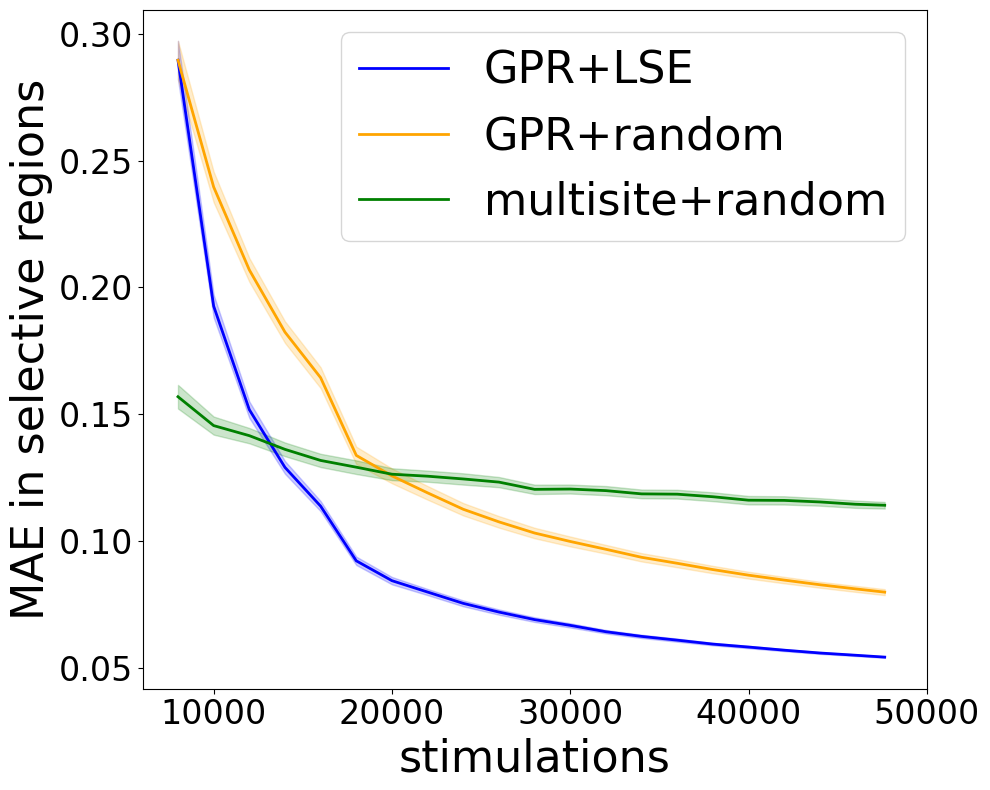

In [19]:
# Calculate mean and confidence intervals
mean_performance = np.mean(MAEs_all_array, axis=0)
mean_performance_uniform = np.mean(MAEs_random_all_array, axis=0)
mean_performance_multisite = np.mean(MAEs_multisite_all_array, axis=0)

std_performance = np.std(MAEs_all_array, axis=0)
std_performance_uniform = np.std(MAEs_random_all_array, axis=0)
std_performance_multisite = np.std(MAEs_multisite_all_array, axis=0)

# 95% confidence interval (1.96 for normal distribution)
ci_performance = 1.96 * (std_performance / np.sqrt(MAEs_all_array.shape[0]))
ci_performance_uniform = 1.96 * (std_performance_uniform / np.sqrt(MAEs_random_all_array.shape[0]))
ci_performance_multisite = 1.96 * (std_performance_multisite / np.sqrt(MAEs_multisite_all_array.shape[0]))

# Average number of samples (x-axis)
avg_num_samples = np.mean(num_samples_all_array, axis=0)

# Plot
plt.figure(figsize=(10, 8))

# Optimal sampling plot
plt.plot(avg_num_samples*20, mean_performance, label="GPR+LSE", color='blue', linewidth=2)
plt.fill_between(avg_num_samples*20, mean_performance - ci_performance, mean_performance + ci_performance, 
                 color='blue', alpha=0.2)

# Random sampling plot
plt.plot(avg_num_samples*20, mean_performance_uniform, label="GPR+random", color='orange', linewidth=2)
plt.fill_between(avg_num_samples*20, mean_performance_uniform - ci_performance_uniform, mean_performance_uniform + ci_performance_uniform, 
                 color='orange', alpha=0.2)

# Multisite sampling plot
plt.plot(avg_num_samples*20, mean_performance_multisite, label="multisite+random", color='green', linewidth=2)
plt.fill_between(avg_num_samples*20, mean_performance_multisite - ci_performance_multisite, mean_performance_multisite + ci_performance_multisite, 
                 color='green', alpha=0.2)

# Labels and legend
plt.xlabel("stimulations", fontsize=32)
plt.ylabel("MAE in selective regions", fontsize=32)
plt.xticks([10000, 20000, 30000, 40000, 50000], fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=32)
plt.tight_layout()
# plt.savefig(f'/Volumes/Lab/Users/praful/multielectrode/figures/fig6/fig6_gp-lse_vs_random_MAE_{dataset}_p{pattern}-multisite-data-stims.png', dpi=300)
plt.show()

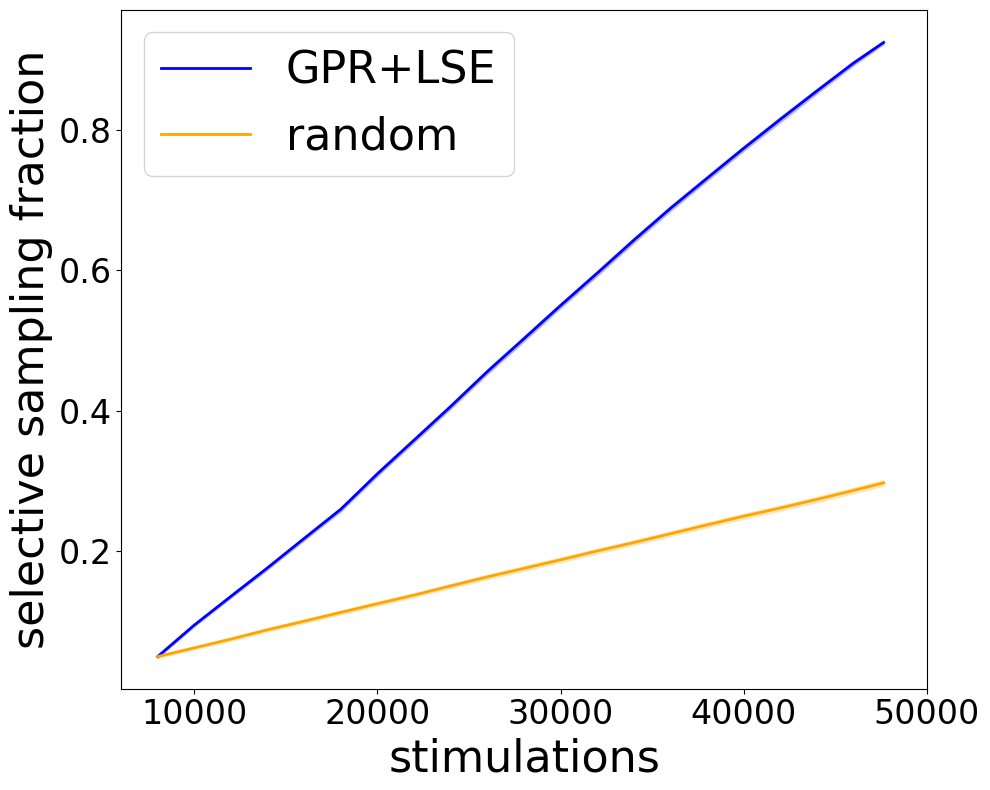

In [21]:
# Calculate mean and confidence intervals
mean_performance = np.mean(success_fractions_all_array, axis=0)
mean_performance_uniform = np.mean(success_fractions_random_all_array, axis=0)

std_performance = np.std(success_fractions_all_array, axis=0)
std_performance_uniform = np.std(success_fractions_random_all_array, axis=0)

# 95% confidence interval (1.96 for normal distribution)
ci_performance = 1.96 * (std_performance / np.sqrt(success_fractions_all_array.shape[0]))
ci_performance_uniform = 1.96 * (std_performance_uniform / np.sqrt(success_fractions_random_all_array.shape[0]))

# Average number of samples (x-axis)
avg_num_samples = np.mean(num_samples_all_array, axis=0)

# Plot
plt.figure(figsize=(10, 8))

# Optimal sampling plot
plt.plot(avg_num_samples*20, mean_performance, label="GPR+LSE", color='blue', linewidth=2)
plt.fill_between(avg_num_samples*20, mean_performance - ci_performance, mean_performance + ci_performance, 
                 color='blue', alpha=0.2)

# Random sampling plot
plt.plot(avg_num_samples*20, mean_performance_uniform, label="random", color='orange', linewidth=2)
plt.fill_between(avg_num_samples*20, mean_performance_uniform - ci_performance_uniform, mean_performance_uniform + ci_performance_uniform, 
                 color='orange', alpha=0.2)

# Labels and legend
plt.xlabel("stimulations", fontsize=32)
plt.ylabel("selective sampling fraction", fontsize=32)
plt.xticks([10000, 20000, 30000, 40000, 50000], fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=32)
plt.tight_layout()
# plt.savefig(f'/Volumes/Lab/Users/praful/multielectrode/figures/fig6/fig6_gp-lse_vs_random_success-fractions_{dataset}_p{pattern}-multisite-data-stims.png', dpi=300)
plt.show()